In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [166]:
dataset=pd.read_csv(r"D:\python\Machine Learning and Data Science Capstone Project\2.Data preprocessing\cleaned_saas_sales.csv")

In [167]:
dataset

,Country,City,Region,Subregion,Customer,Industry,Segment,Product,Sales,Quantity,Discount,Profit,Year,Month,Day
0,Ireland,Dublin,EMEA,UKIR,Chevron,Energy,SMB,Marketing Suite,261.9600,2.0,0.00,41.9136,2022,11,9
1,Ireland,Dublin,EMEA,UKIR,Chevron,Energy,SMB,FinanceHub,731.9400,3.0,0.00,219.5820,2022,11,9
2,United States,New York City,AMER,NAMER,Phillips 66,Energy,Strategic,FinanceHub,14.6200,2.0,0.00,6.8714,2022,6,13
3,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,Energy,SMB,ContactMatcher,957.5775,5.0,0.45,-383.0310,2021,10,11
4,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,Energy,SMB,Marketing Suite - Gold,22.3680,2.0,0.20,2.5164,2021,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,Healthcare,SMB,SaaS Connector Pack,25.2480,3.0,0.20,4.1028,2020,1,22
9990,United States,Milwaukee,AMER,NAMER,American Express,Finance,SMB,SaaS Connector Pack,91.9600,2.0,0.00,15.6332,2023,2,27
9991,United States,Milwaukee,AMER,NAMER,American Express,Finance,SMB,Site Analytics,258.5760,2.0,0.20,19.3932,2023,2,27
9992,United States,Milwaukee,AMER,NAMER,American Express,Finance,SMB,Support,29.6000,4.0,0.00,13.3200,2023,2,27


In [168]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    9994 non-null   str    
 1   City       9994 non-null   str    
 2   Region     9994 non-null   str    
 3   Subregion  9994 non-null   str    
 4   Customer   9994 non-null   str    
 5   Industry   9994 non-null   str    
 6   Segment    9994 non-null   str    
 7   Product    9994 non-null   str    
 8   Sales      9994 non-null   float64
 9   Quantity   9994 non-null   float64
 10  Discount   9994 non-null   float64
 11  Profit     9994 non-null   float64
 12  Year       9994 non-null   int64  
 13  Month      9994 non-null   int64  
 14  Day        9994 non-null   int64  
dtypes: float64(4), int64(3), str(8)
memory usage: 1.1 MB


In [169]:
numeric=dataset.select_dtypes(include=["float"]).columns

In [170]:
numeric

Index(['Sales', 'Quantity', 'Discount', 'Profit'], dtype='str')

In [171]:
dataset[numeric]

,Sales,Quantity,Discount,Profit
0,261.9600,2.0,0.00,41.9136
1,731.9400,3.0,0.00,219.5820
2,14.6200,2.0,0.00,6.8714
3,957.5775,5.0,0.45,-383.0310
4,22.3680,2.0,0.20,2.5164
...,...,...,...,...
9989,25.2480,3.0,0.20,4.1028
9990,91.9600,2.0,0.00,15.6332
9991,258.5760,2.0,0.20,19.3932
9992,29.6000,4.0,0.00,13.3200


In [172]:
categorical=dataset.select_dtypes(include=["object","str"]).columns

In [173]:
categorical

Index(['Country', 'City', 'Region', 'Subregion', 'Customer', 'Industry',
       'Segment', 'Product'],
      dtype='str')

# Frequency table 

In [174]:
for columnname in categorical :
     frequency_table=pd.DataFrame(columns=["Unique_values","Frequency","Relative_Frequency","cusum"])

In [175]:
frequency_table

,Unique_values,Frequency,Relative_Frequency,cusum


In [176]:
freq = dataset[columnname].value_counts()

In [177]:
freq

Product
ContactMatcher                1842
Support                       1560
FinanceHub                     981
SaaS Connector Pack            957
Site Analytics                 889
Marketing Suite - Gold         846
ChatBot Plugin                 796
Data Smasher                   775
OneView                        466
SaaS Connector Pack - Gold     254
Marketing Suite                228
Storage                        217
Big Ol Database                115
Alchemy                         68
Name: count, dtype: int64

In [178]:

def freq_table(dataset):

    result = {}

    for columnname in categorical:

        freq = dataset[columnname].value_counts()

        freqTable = pd.DataFrame({
            "Unique_Values": freq.index,
            "Frequency": freq.values,
            "Relative Frequency": freq.values / len(dataset),
            'Cumulative Frequency': freq.cumsum(),
            "Percentage": (freq.values / len(dataset)) * 100
        })

        result[columnname] = freqTable

    return result

In [179]:
freq_table(dataset)

{'Country':                              Unique_Values  Frequency  Relative Frequency  \
 Country                                                                     
 United States                United States       2001            0.200220   
 United Kingdom              United Kingdom       1141            0.114169   
 Japan                                Japan        985            0.098559   
 France                              France        587            0.058735   
 Canada                              Canada        506            0.050630   
 Australia                        Australia        492            0.049230   
 Mexico                              Mexico        469            0.046928   
 Germany                            Germany        383            0.038323   
 Brazil                              Brazil        255            0.025515   
 Sweden                              Sweden        249            0.024915   
 Chile                                Chile        22

Descriptive statics for numeric columns
Mean
Median
Mode
Standard deviation
Minimum / Maximum
Quartiles
Frequency counts

In [180]:

descriptive = pd.DataFrame(
    index=[
        "Mean",
        "Median",
        "Mode",
        "Q1:25%",
        "Q2:50%",
        "Q3:75%",
        "IQR",
        "1.5 Rule",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count",
        "Standard deviation",
        "Minimum",
        "Maximum",
        "Frequency counts"
    ],
    columns=numeric
)

In [181]:
descriptive

,Sales,Quantity,Discount,Profit
Mean,NaN,NaN,NaN,NaN
Median,NaN,NaN,NaN,NaN
Mode,NaN,NaN,NaN,NaN
Q1:25%,NaN,NaN,NaN,NaN
Q2:50%,NaN,NaN,NaN,NaN
Q3:75%,NaN,NaN,NaN,NaN
IQR,NaN,NaN,NaN,NaN
1.5 Rule,NaN,NaN,NaN,NaN
Lower Limit,NaN,NaN,NaN,NaN
Upper Limit,NaN,NaN,NaN,NaN


In [182]:
for cols in numeric:

    descriptive.loc["Mean", cols] = dataset[cols].mean()

    descriptive.loc["Median", cols] = dataset[cols].median()

    descriptive.loc["Mode", cols] = dataset[cols].mode()[0]

    # Quartiles
    descriptive.loc["Q1:25%", cols] = dataset[cols].quantile(0.25)

    descriptive.loc["Q2:50%", cols] = dataset[cols].quantile(0.50)

    descriptive.loc["Q3:75%", cols] = dataset[cols].quantile(0.75)

    # IQR
    descriptive.loc["IQR", cols] = (descriptive.loc["Q3:75%", cols]-descriptive.loc["Q1:25%", cols])

    # 1.5 Rule
    descriptive.loc["1.5 Rule", cols] = (1.5 * descriptive.loc["IQR", cols])

    # Lower Boundary
    descriptive.loc["Lower Limit", cols] = (descriptive.loc["Q1:25%", cols]-descriptive.loc["1.5 Rule", cols])

    # Upper Boundary
    descriptive.loc["Upper Limit", cols] = (descriptive.loc["Q3:75%", cols]+descriptive.loc["1.5 Rule", cols])

    # Outliers
    lower = descriptive.loc["Lower Limit", cols]

    upper = descriptive.loc["Upper Limit", cols]

    outliers = dataset[
        (dataset[cols] < lower) |
        (dataset[cols] > upper)
    ][cols]

    descriptive.loc["Outlier Count", cols] = len(outliers)

    # Other Statistics
    descriptive.loc["Standard deviation", cols] = dataset[cols].std()

    descriptive.loc["Minimum", cols] = dataset[cols].min()

    descriptive.loc["Maximum", cols] = dataset[cols].max()

    descriptive.loc["Frequency counts", cols] = str(dataset[cols].value_counts().head().to_dict()
    )

    

In [183]:
descriptive

,Sales,Quantity,Discount,Profit
Mean,229.858001,3.789574,0.156203,28.656896
Median,54.49,3.0,0.2,8.6665
Mode,12.96,3.0,0.0,0.0
Q1:25%,17.28,2.0,0.0,1.72875
Q2:50%,54.49,3.0,0.2,8.6665
Q3:75%,209.94,5.0,0.2,29.364
IQR,192.66,3.0,0.2,27.63525
1.5 Rule,288.99,4.5,0.3,41.452875
Lower Limit,-271.71,-2.5,-0.3,-39.724125
Upper Limit,498.93,9.5,0.5,70.816875


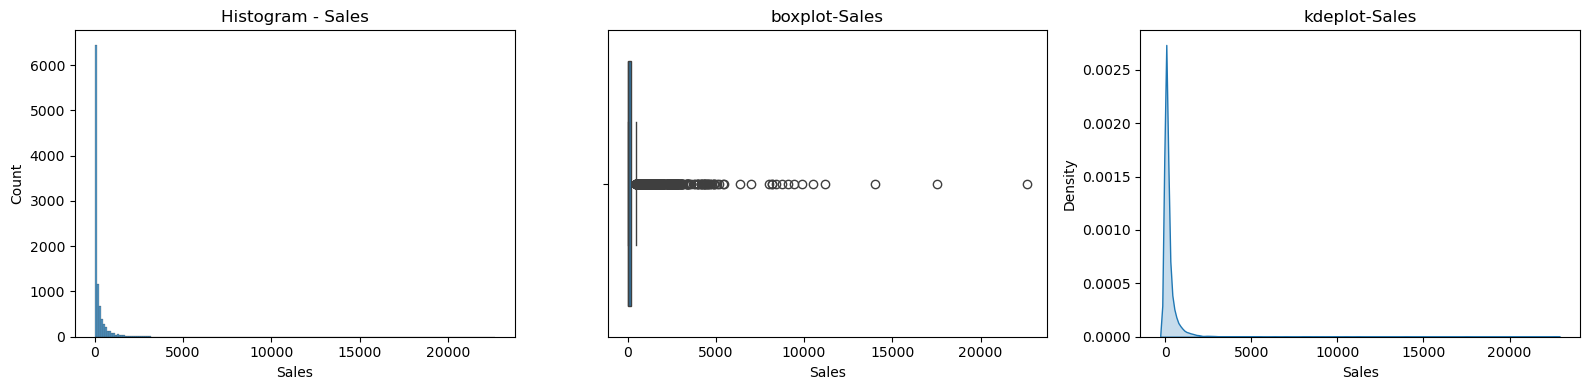

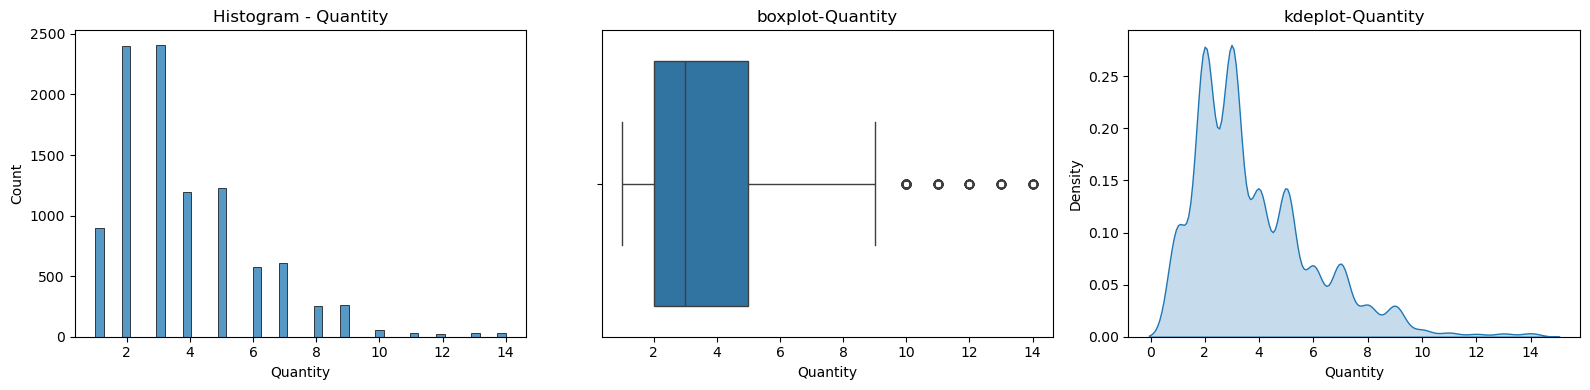

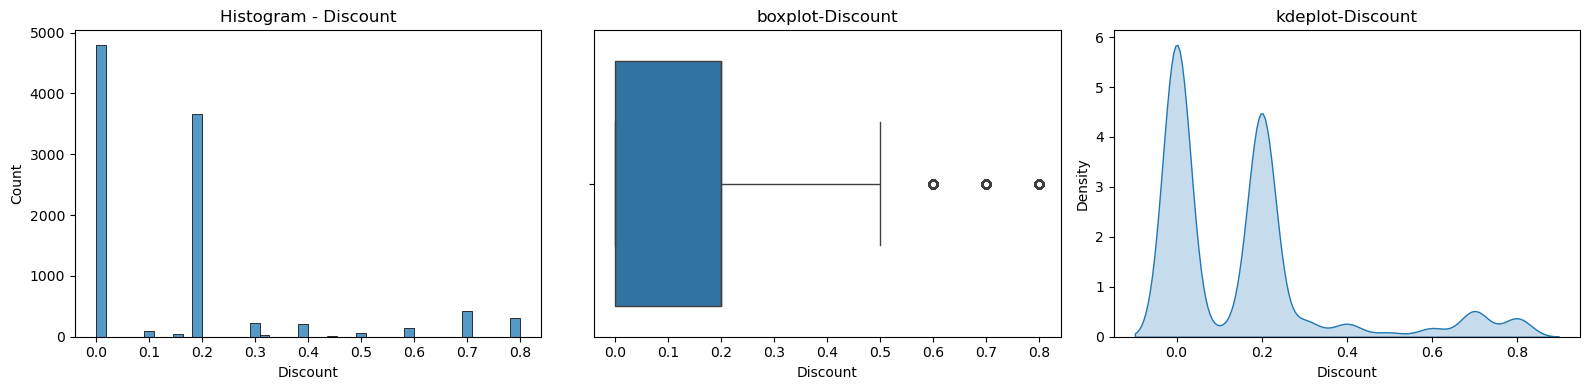

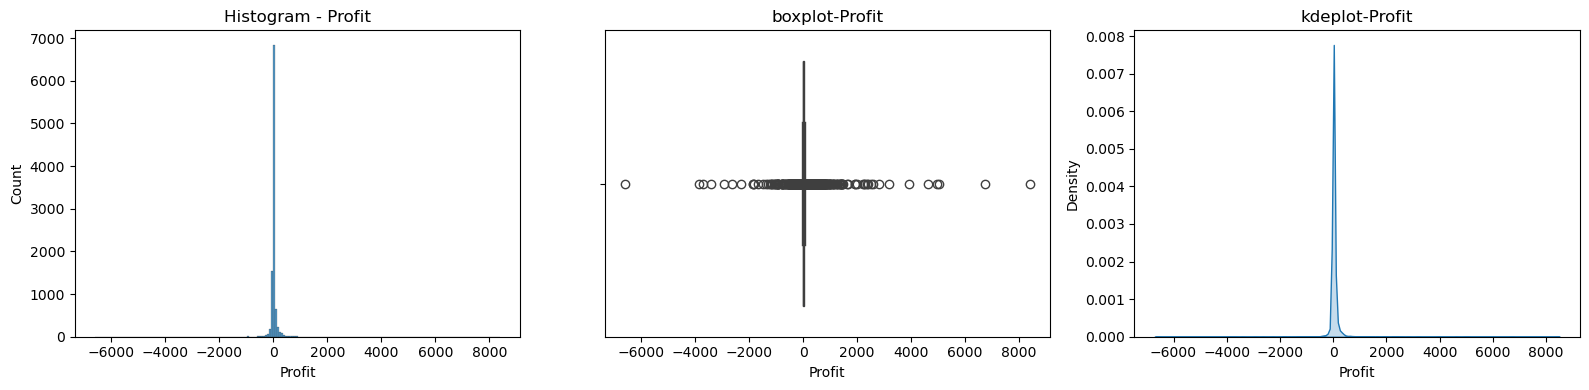

In [208]:
for cols in numeric:
    plt.figure(figsize=(16,4))

    #histogram
    plt.subplot(1,3,1)
    sns.histplot(dataset[cols],kde=False)
    plt.title(f'Histogram - {cols}')
    #boxplot
    plt.subplot(1,3,2)
    sns.boxplot(x=dataset[cols])
    plt.title(f"boxplot-{cols}")
    #kde plot
    plt.subplot(1,3,3)
    sns.kdeplot(dataset[cols],fill=True)
    plt.title(f"kdeplot-{cols}")

    # Adjust spacing
    plt.tight_layout()

    # Display plots
    plt.show()